# Oasis Infobyte Internship — Task 3\n
## Car Price Prediction with Machine Learning\n\n
**Objective:** Predict the selling price of a used car using car age, brand, mileage, fuel type, transmission and other vehicle attributes.\n\n
This notebook is beginner-friendly and demonstrates the complete ML workflow: data loading → cleaning → feature engineering → EDA → preprocessing → model training → evaluation → best-model selection → saving the model.

### Dataset note\n
The included CSV is a self-contained, realistic used-car dataset based on the common CarDekho-style schema. It is included so the project runs offline and reproducibly. The notebook does not depend on a Kaggle download.

In [5]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Work from the project root so the notebook is portable

PROJECT_ROOT = (
    os.path.abspath(os.path.join(os.getcwd(), '..'))
    if os.path.basename(os.getcwd()) == 'notebooks'
    else os.getcwd()
)

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    'data',
    'used_car_price_dataset.csv'
)

MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')

os.makedirs(MODEL_DIR, exist_ok=True)

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

df.head()

Shape: (502, 9)


,name,year,selling_price_lakh,km_driven,fuel,seller_type,transmission,owner,engine_cc
0,Hyundai i20,2013,4.24,110701.0,Diesel,Individual,Manual,Second Owner,1770.0
1,Tata Nexon,2019,4.97,96685.0,Diesel,Individual,Manual,First Owner,1548.0
2,Kia Sonet,2018,6.34,130752.0,CNG,Dealer,Manual,Second Owner,2197.0
3,Renault Triber,2016,3.20,134798.0,Petrol,Individual,Manual,Second Owner,1881.0
4,Honda Jazz,2016,6.21,101048.0,Petrol,Individual,Manual,First Owner,823.0


## 1. Data Understanding and Cleaning

In [10]:
df.info()
print('\\nMissing values:')
print(df.isnull().sum())
print('\\nDuplicate rows:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                502 non-null    str    
 1   year                502 non-null    int64  
 2   selling_price_lakh  502 non-null    float64
 3   km_driven           501 non-null    float64
 4   fuel                502 non-null    str    
 5   seller_type         502 non-null    str    
 6   transmission        502 non-null    str    
 7   owner               502 non-null    str    
 8   engine_cc           501 non-null    float64
dtypes: float64(3), int64(1), str(5)
memory usage: 35.4 KB
\nMissing values:
name                  0
year                  0
selling_price_lakh    0
km_driven             1
fuel                  0
seller_type           0
transmission          0
owner                 0
engine_cc             1
dtype: int64
\nDuplicate rows: 2


In [11]:
# Standardize categorical text to remove inconsistencies such as 'petrol' vs 'Petrol'.\n
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    df[col] = df[col].astype('string').str.strip().str.title()

# Remove exact duplicate rows.\n
df = df.drop_duplicates().reset_index(drop=True)

# Feature engineering: car age and brand.\n
CURRENT_YEAR = 2026
df['car_age'] = CURRENT_YEAR - df['year']
df['brand'] = df['name'].str.split().str[0].str.title()

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (500, 11)


,name,year,selling_price_lakh,km_driven,fuel,seller_type,transmission,owner,engine_cc,car_age,brand
0,Hyundai i20,2013,4.24,110701.0,Diesel,Individual,Manual,Second Owner,1770.0,13,Hyundai
1,Tata Nexon,2019,4.97,96685.0,Diesel,Individual,Manual,First Owner,1548.0,7,Tata
2,Kia Sonet,2018,6.34,130752.0,Cng,Dealer,Manual,Second Owner,2197.0,8,Kia
3,Renault Triber,2016,3.20,134798.0,Petrol,Individual,Manual,Second Owner,1881.0,10,Renault
4,Honda Jazz,2016,6.21,101048.0,Petrol,Individual,Manual,First Owner,823.0,10,Honda


## 2. Exploratory Data Analysis

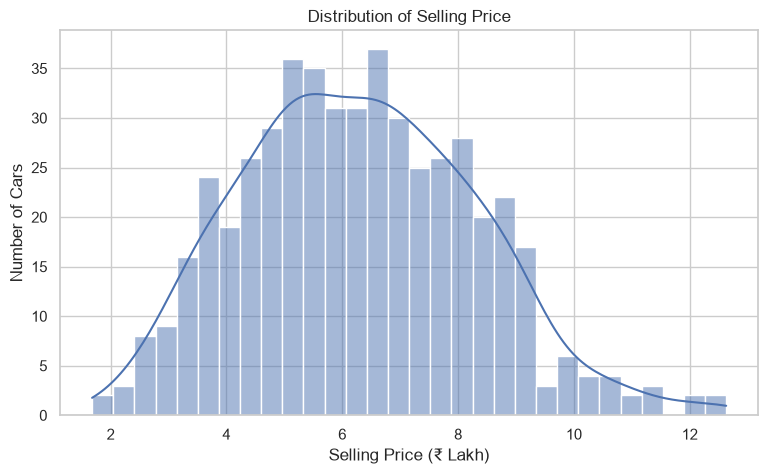

In [12]:
plt.figure(figsize=(9,5))
sns.histplot(df['selling_price_lakh'], kde=True, bins=30)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (₹ Lakh)')
plt.ylabel('Number of Cars')
plt.show()

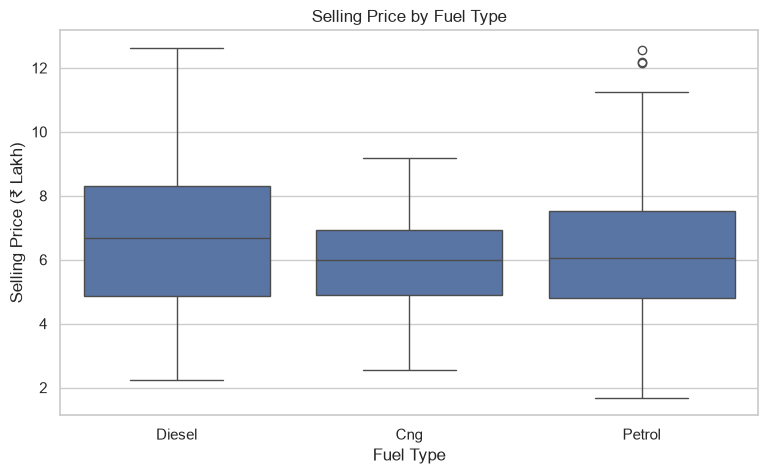

In [14]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price_lakh'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (₹ Lakh)')
plt.show()

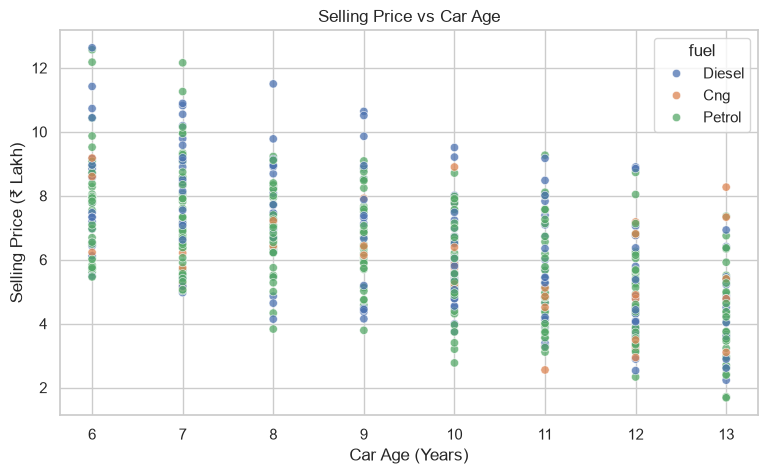

In [15]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price_lakh',
    hue='fuel',
    alpha=0.75
)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (₹ Lakh)')
plt.show()

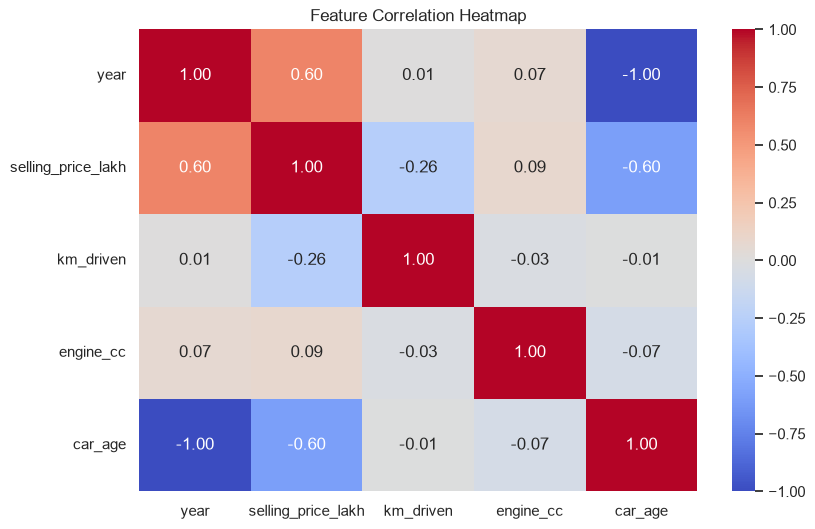

In [16]:
numeric_cols = [
    'year',
    'selling_price_lakh',
    'km_driven',
    'engine_cc',
    'car_age'
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

### EDA observations\n- Older cars generally have lower selling prices.\n- Higher mileage tends to reduce resale value.\n- Fuel type and transmission create useful price differences.\n- Brand and engine size can also influence price.

## 3. Prepare Features and Target

In [17]:
target = 'selling_price_lakh'

features = [
    'car_age',
    'km_driven',
    'engine_cc',
    'brand',
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

X = df[features]
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Separate numerical and categorical features
numeric_features = [
    'car_age',
    'km_driven',
    'engine_cc'
]

categorical_features = [
    'brand',
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

# Numerical preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 4. Train Regression Models\nWe compare Linear Regression, Decision Tree and Random Forest. Pipelines keep preprocessing and modeling together and help prevent data leakage.

In [18]:
models = {
    'Linear Regression': LinearRegression(),

    'Decision Tree': DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=3,
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
results = []

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict
    pred = pipe.predict(X_test)

    # Evaluation metrics
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    # Save trained pipeline
    trained_models[name] = pipe

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

# Create comparison table
results_df = (
    pd.DataFrame(results)
    .sort_values('R2', ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.588262,0.530672,0.728473,0.886673
1,Random Forest,0.883098,1.296309,1.138556,0.723169
2,Decision Tree,0.978270,1.511290,1.229345,0.677259


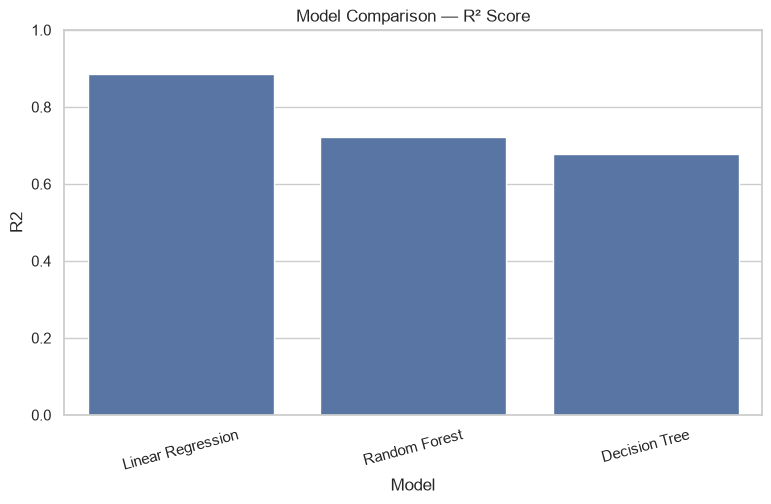

In [19]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2'
)

plt.ylim(0, 1)
plt.title('Model Comparison — R² Score')
plt.xticks(rotation=15)
plt.show()

## 5. Select the Best Model and Inspect Feature Importance

In [20]:
best_name = results_df.loc[0, 'Model']
best_model = trained_models[best_name]

print('Best model:', best_name)
print('Best R²:', round(results_df.loc[0, 'R2'], 4))

if best_name in ['Decision Tree', 'Random Forest']:

    feature_names = (
        best_model
        .named_steps['preprocessor']
        .get_feature_names_out()
    )

    importances = (
        best_model
        .named_steps['model']
        .feature_importances_
    )

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    importance_df = (
        importance_df
        .sort_values('Importance', ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=importance_df,
        y='Feature',
        x='Importance'
    )

    plt.title(f'Top Feature Importances — {best_name}')
    plt.show()

else:
    print(
        'Feature importance chart is not available for Linear Regression; '
        'coefficients could be inspected instead.'
    )

Best model: Linear Regression
Best R²: 0.8867
Feature importance chart is not available for Linear Regression; coefficients could be inspected instead.


## 6. Save the Best Model

In [21]:
MODEL_PATH = os.path.join(
    MODEL_DIR,
    'best_car_price_model.joblib'
)

joblib.dump(best_model, MODEL_PATH)

print('Saved:', MODEL_PATH)

Saved: c:\Users\MHD\OneDrive\Pictures\Desktop\OIBSIP\OASIS_TASK3_Car_Price_Prediction\models\best_car_price_model.joblib


## 7. Example Prediction

In [22]:
sample_car = pd.DataFrame([{
    'car_age': 5,
    'km_driven': 45000,
    'engine_cc': 1200,
    'brand': 'Hyundai',
    'fuel': 'Petrol',
    'seller_type': 'Individual',
    'transmission': 'Manual',
    'owner': 'First Owner'
}])

predicted_price = best_model.predict(sample_car)[0]

print(f'Estimated selling price: ₹{predicted_price:.2f} lakh')

Estimated selling price: ₹8.10 lakh


## Conclusion\nThe project demonstrates a complete regression workflow for used-car price prediction. Multiple models were trained and compared using MAE, MSE, RMSE and R². The model with the strongest R² score is selected and saved for reuse.

**Note:** This is an educational internship project. Predictions are estimates and should not be treated as real-world vehicle valuations.